# 03 XAI SHAP — Revised Workflow

This notebook uses `xai_research_utils.py` to run SHAP on selected HDFS sequences from the semantic prediction database. The workflow is:

1. load model and training windows,
2. build sequence-level samples from the prediction database,
3. run SHAP for sampled TP/TN/FP/FN cases,
4. summarize SHAP results,
5. optionally run a simple top-SHAP vs random-position ablation check.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import Transformer as tnsf

from xai_shap import (
    load_hdfs_windows,
    infer_event_vocabulary_from_train,
    build_sequence_level_semantic_df,
    make_stratified_shap_sample,
    run_shap_for_sample,
    inspect_token_predictions,
    run_top_shap_vs_random_ablation,
    summarize_ablation,
    load_dataframe,
    save_dataframe,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = getattr(tnsf, "device", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
WINDOW_SIZE = getattr(tnsf, "WINDOW_SIZE", 10)
PAD_ID = getattr(tnsf, "PAD", 0)
BOS_ID = getattr(tnsf, "BOS", 32)
VOCAB_SIZE = getattr(tnsf, "VOCAB_SIZE", BOS_ID + 1)
TOP_K = 9

MODEL_PATH = Path("Model/centralized_model.pt")
TRAIN_PATH = Path("Dataset/HDFS/hdfs_train")
SEMANTIC_DB_PATH = Path("prediction_db.csv")

BACKGROUND_SIZE = 50
MAX_EVALS = 220
SCORE_TYPE = "topk_margin_log_prob"  # Use "true_log_prob" if explaining confidence in the true event.

N_PER_STRATUM = 50
MAX_PRIORITY_PER_STRATUM = 200
MAX_SEQUENCES_FOR_TEST_RUN = 20  # Set to None after the test run works.

OUTPUT_SAMPLE_PATH = Path("xai_shap_sequence_sample.csv")
OUTPUT_SHAP_PATH = Path("token_shap_db_revised.csv")
OUTPUT_SUMMARY_PATH = Path("token_shap_summary_revised.csv")
OUTPUT_ABLATION_PATH = Path("top_shap_vs_random_ablation.csv")

print("DEVICE:", DEVICE)
print("WINDOW_SIZE:", WINDOW_SIZE, "PAD:", PAD_ID, "BOS:", BOS_ID, "VOCAB_SIZE:", VOCAB_SIZE)


DEVICE: cpu
WINDOW_SIZE: 10 PAD: 0 BOS: 33 VOCAB_SIZE: 34


## 1. Verify BOS and Other Token

In [2]:
if TRAIN_PATH.exists():
    vocab_info = infer_event_vocabulary_from_train(TRAIN_PATH, pad_id=PAD_ID)
    print(vocab_info)
else:
    vocab_info = None
    print("TRAIN_PATH not found. Skipping vocabulary check.")


{'pad_id': 0, 'max_event_id': 32, 'bos_id': 33, 'vocab_size': 34, 'unique_event_ids': [1, 2, 3, 4, 5, 6, 7, 8, 9, 13, 23, 25, 32]}


## 2. Load training windows for SHAP background

In [3]:
background_src, background_tgt = load_hdfs_windows(
    TRAIN_PATH,
    window_size=WINDOW_SIZE,
    pad_id=PAD_ID,
)

print("background_src:", background_src.shape)


background_src: (4982, 10)


## 3. Load pre-trained Transformer

In [4]:
state = torch.load(MODEL_PATH, map_location=DEVICE)

if isinstance(state, dict):
    VOCAB_SIZE = state["src_embed.0.lut.weight"].shape[0]
    D_MODEL = state["src_embed.0.lut.weight"].shape[1]
    D_FF = state.get("encoder.layers.0.feed_forward.w_1.weight", torch.empty(2048)).shape[0]
    N_LAYERS = len({k.split(".")[2] for k in state if k.startswith("encoder.layers.")})
    BOS_ID = VOCAB_SIZE - 1

    model = tnsf.make_model(
        VOCAB_SIZE,
        VOCAB_SIZE,
        N=N_LAYERS,
        d_model=D_MODEL,
        d_ff=D_FF,
        h=4,
        dropout=0.1,
    )
    model.load_state_dict(state)
else:
    model = state
    VOCAB_SIZE = model.src_embed[0].lut.num_embeddings
    BOS_ID = VOCAB_SIZE - 1
    N_LAYERS = len(model.encoder.layers)

model = model.to(DEVICE)
model.eval()

print("Model loaded.")
print("VOCAB_SIZE:", VOCAB_SIZE)
print("BOS_ID:", BOS_ID)
print("N_LAYERS:", N_LAYERS)


Model loaded.
VOCAB_SIZE: 33
BOS_ID: 32
N_LAYERS: 4


## 4. Build sequence-level sample from semantic DB

This converts the token-level semantic database into one row per sequence, then samples TP/TN/FP/FN strata.

In [ ]:
pred_db = load_dataframe(SEMANTIC_DB_PATH)

print("Prediction DB rows:", len(pred_db))
print("Prediction DB columns:", pred_db.columns.tolist())

seq_df = build_sequence_level_semantic_df(
    pred_db,
    pad_id=PAD_ID,
    bos_id=BOS_ID,
)

print("Sequence-level rows:", len(seq_df))
display(seq_df["stratum"].value_counts(dropna=False))

shap_sample = make_stratified_shap_sample(
    seq_df,
    n_per_stratum=N_PER_STRATUM,
    seed=SEED,
    priority_strata=("False Positive", "False Negative"),
    max_priority_per_stratum=MAX_PRIORITY_PER_STRATUM,
)

save_dataframe(shap_sample, OUTPUT_SAMPLE_PATH)

print("Saved sample:", OUTPUT_SAMPLE_PATH, "rows:", len(shap_sample))
display(shap_sample.head())


c:\01. Monash University\controlroom-xai-alarm-support-transformer\notebooks\xai_shap.py:679: DtypeWarning: Columns (0: results_matrix, 1: sequence_results_matrix) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


Prediction DB rows: 4679295
Prediction DB columns: ['dataset', 'seq_id', 'sequence', 'seq_len', 'input_seq', 'target_seq', 'pred_events', 'pred_probs', 'target_event', 'target_event_is_unseen', 'target_in_topk_pred', 'target_in_pred_pos', 'target_in_topk_pred_prob', 'predicted_status', 'results', 'results_matrix', 'sequence_predicted_status', 'sequence_results_matrix']
Sequence-level rows: 568870


stratum
True Negative     546947
True Positive       8601
False Positive      6294
NaN                 4982
False Negative      2046
Name: count, dtype: int64

Saved sample: xai_shap_sequence_sample.csv rows: 550


,dataset,seq_id,sequence,seq_len,input_seq,target_seq,sequence_predicted_status,sequence_results_matrix,target_event_is_unseen,target_in_topk_pred,target_in_pred_pos,target_in_topk_pred_prob,results,results_matrix,n_token_rows,stratum,shap_sample_id
0,abnormal_test,5083,2 1 1 1 5 3 4 5 5 3 4 3 4 6 6 25 6 6 25 6 6 25...,29,"[2, 1, 1, 1, 5, 3, 4, 5, 5, 3]",[4],normal,False Negative,False,1.0,2.8,0.454893,1.0,False Negative,10,False Negative,0
1,abnormal_test,6468,1 1 1 2 3 4 3 4 3 4 5 5 5 6 6 25 9 6 25 6 23 2...,27,"[1, 1, 1, 2, 3, 4, 3, 4, 3, 4]",[5],normal,False Negative,False,1.0,4.8,0.284587,1.0,False Negative,10,False Negative,1
2,abnormal_test,13829,2 1 1 1 3 4 3 4 3 4 5 5 5 8 7 1 4 6 5 5 13 23 ...,27,"[2, 1, 1, 1, 3, 4, 3, 4, 3, 4]",[5],abnormal,True Positive,False,0.7,3.0,0.415875,0.7,False Negative|True Positive,10,True Positive,2
3,abnormal_test,7403,1 2 1 1 3 4 3 4 3 4 5 5 5 6 6 25 23 23 23 13 1...,23,"[1, 2, 1, 1, 3, 4, 3, 4, 3, 4]",[5],normal,False Negative,False,1.0,2.9,0.461084,1.0,False Negative,10,False Negative,3
4,train,275,2 1 1 1 5 5 3 4 3 4 5 3 4 25 25 6 23 23 23 13 ...,22,"[2, 1, 1, 1, 5, 5, 3, 4, 3, 4]",[5],normal,NaN,False,1.0,1.9,0.401903,1.0,,10,NaN,4


## 5. Quick sanity test on one sampled sequence

In [10]:
sample_row = shap_sample.iloc[0]

pred_preview = inspect_token_predictions(
    model=model,
    tnsf=tnsf,
    src_seq=sample_row["input_seq"],
    tgt_seq=sample_row["target_seq"],
    top_k=TOP_K,
    window_size=WINDOW_SIZE,
    bos_id=BOS_ID,
    pad_id=PAD_ID,
    device=DEVICE,
)

display(pred_preview)


,step_idx,true_event_id,predicted_event_id,true_log_prob,topk_boundary_log_prob,topk_margin_log_prob,hit_top_1,hit_top_k,top_k_event_ids,top_k_log_probs
0,0,4,4,-0.00971,-17.654984,17.645274,1,1,"[4, 3, 9, 5, 25, 24, 22, 12, 2]","[-0.009709631092846394, -4.6396355628967285, -..."


## 6. Run SHAP for the sampled sequences

First run only `MAX_SEQUENCES_FOR_TEST_RUN`. After it works, set it to `None` for the full sample.

In [7]:
token_shap_db = run_shap_for_sample(
    sample_df=shap_sample,
    model=model,
    tnsf=tnsf,
    background_src=background_src,
    output_path=OUTPUT_SHAP_PATH,
    top_k=TOP_K,
    window_size=WINDOW_SIZE,
    bos_id=BOS_ID,
    pad_id=PAD_ID,
    device=DEVICE,
    background_size=BACKGROUND_SIZE,
    max_evals=MAX_EVALS,
    seed=SEED,
    score_type=SCORE_TYPE,
    max_sequences=MAX_SEQUENCES_FOR_TEST_RUN,
    save_every=5,
)

print("Rows:", len(token_shap_db))
display(token_shap_db.head())


C:\Users\miqba\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PermutationExplainer explainer: 2it [00:14, 14.79s/it]               


Saved checkpoint: token_shap_db_revised_part_001.csv | sequences processed: 5
Saved checkpoint: token_shap_db_revised_part_002.csv | sequences processed: 10
Saved checkpoint: token_shap_db_revised_part_003.csv | sequences processed: 15
Saved checkpoint: token_shap_db_revised_part_004.csv | sequences processed: 20
Final SHAP DB saved: token_shap_db_revised.csv
Rows: 200 | elapsed: 162.4s
Rows: 200


,step_idx,src_position,src_event_id,true_next_event_id,score_type,shap_value,abs_shap_value,shap_rank,shap_share,base_value,...,stratum,sequence_predicted_status,sequence_results_matrix,target_event_is_unseen,target_in_topk_pred,target_in_pred_pos,target_in_topk_pred_prob,n_token_rows,input_seq,target_seq
0,0,5,5,4,topk_margin_log_prob,3.929252,3.929252,1,0.573029,11.691194,...,False Negative,normal,False Negative,False,1.0,2.8,0.454893,10,"[2, 1, 1, 1, 5, 3, 4, 5, 5, 3]",[4]
1,0,8,5,4,topk_margin_log_prob,1.210137,1.210137,2,0.176482,11.691194,...,False Negative,normal,False Negative,False,1.0,2.8,0.454893,10,"[2, 1, 1, 1, 5, 3, 4, 5, 5, 3]",[4]
2,0,9,5,4,topk_margin_log_prob,0.638891,0.638891,3,0.093174,11.691194,...,False Negative,normal,False Negative,False,1.0,2.8,0.454893,10,"[2, 1, 1, 1, 5, 3, 4, 5, 5, 3]",[4]
3,0,7,4,4,topk_margin_log_prob,-0.423758,0.423758,4,0.061799,11.691194,...,False Negative,normal,False Negative,False,1.0,2.8,0.454893,10,"[2, 1, 1, 1, 5, 3, 4, 5, 5, 3]",[4]
4,0,6,3,4,topk_margin_log_prob,0.409100,0.409100,5,0.059662,11.691194,...,False Negative,normal,False Negative,False,1.0,2.8,0.454893,10,"[2, 1, 1, 1, 5, 3, 4, 5, 5, 3]",[4]


## 7. SHAP summary

In [8]:
summary_cols = ["stratum", "src_event_id", "src_position"]

shap_summary = (
    token_shap_db
    .groupby(summary_cols, dropna=False)
    .agg(
        mean_abs_shap=("abs_shap_value", "mean"),
        median_abs_shap=("abs_shap_value", "median"),
        mean_shap_share=("shap_share", "mean"),
        n=("abs_shap_value", "size"),
    )
    .reset_index()
    .sort_values("mean_abs_shap", ascending=False)
)

save_dataframe(shap_summary, OUTPUT_SUMMARY_PATH)

print("Saved summary:", OUTPUT_SUMMARY_PATH)
display(shap_summary.head(30))

Saved summary: token_shap_summary_revised.csv


,stratum,src_event_id,src_position,mean_abs_shap,median_abs_shap,mean_shap_share,n
45,False Positive,5,5,4.670685,5.137244,0.609464,3
85,NaN,5,6,3.960002,3.960002,0.463739,1
84,NaN,5,5,3.790809,3.790809,0.443926,1
46,False Positive,5,6,3.420545,3.420545,0.436952,1
19,False Negative,5,5,2.916482,2.670774,0.442036,5
56,True Negative,5,5,2.538253,2.538253,0.421492,1
57,True Negative,5,6,2.474567,2.474567,0.410917,1
20,False Negative,5,6,2.380173,2.765667,0.367701,4
86,NaN,5,7,1.699051,1.699051,0.562803,1
47,False Positive,5,10,1.585078,1.437456,0.266191,3


## 8. Sanity-check: top-SHAP vs Random-Position ablation

This checks whether perturbing high-SHAP source positions changes the model score more than perturbing random source positions.

In [9]:
seen_event_ids = (
    vocab_info["unique_event_ids"]
    if vocab_info is not None
    else sorted(set(background_src.reshape(-1).tolist()) - {PAD_ID, BOS_ID})
)

ablation_df = run_top_shap_vs_random_ablation(
    shap_db=token_shap_db,
    sequence_df=shap_sample,
    model=model,
    tnsf=tnsf,
    top_m=2,
    top_k=TOP_K,
    window_size=WINDOW_SIZE,
    bos_id=BOS_ID,
    pad_id=PAD_ID,
    device=DEVICE,
    seen_event_ids=seen_event_ids,
    mode="random_event",
    background_src=background_src,
    seed=SEED,
    max_cases=100,
)

save_dataframe(ablation_df, OUTPUT_ABLATION_PATH)

print("Saved ablation:", OUTPUT_ABLATION_PATH)
display(ablation_df.head())
display(summarize_ablation(ablation_df))

Saved ablation: top_shap_vs_random_ablation.csv


,step_idx,top_m,perturbation_mode,top_positions,random_positions,original_true_log_prob,top_shap_true_log_prob,random_true_log_prob,delta_true_log_prob_top_shap,delta_true_log_prob_random,...,top_shap_margin,random_margin,delta_margin_top_shap,delta_margin_random,original_hit_top_k,top_shap_hit_top_k,random_hit_top_k,dataset,seq_id,stratum
0,0,2,random_event,"[6, 5]","[1, 8]",-4.690037,-6.684865,-5.074143,-1.994828,-0.384106,...,5.177945,12.102868,-7.830412,-0.905489,1,1,1,abnormal_test,500,False Negative
1,0,2,random_event,"[5, 6]","[3, 7]",-0.152312,-0.596152,-0.152505,-0.443840,-0.000193,...,11.068972,11.916221,-0.849286,-0.002037,1,1,1,abnormal_test,777,False Negative
2,0,2,random_event,"[5, 6]","[7, 8]",-0.151654,-0.261947,-0.154827,-0.110293,-0.003173,...,11.590837,11.906805,-0.330173,-0.014205,1,1,1,abnormal_test,1538,False Negative
3,0,2,random_event,"[5, 7]","[4, 2]",-4.720512,-4.711589,-4.695522,0.008923,0.024990,...,12.989343,13.021546,-0.005277,0.026926,1,1,1,abnormal_test,2150,False Negative
4,0,2,random_event,"[6, 5]","[10, 5]",-0.008952,-0.009511,-0.009133,-0.000559,-0.000181,...,17.660182,17.684676,-0.045998,-0.021504,1,1,1,abnormal_test,4882,False Negative


,n_cases,mean_delta_true_log_prob_top_shap,mean_delta_true_log_prob_random,median_delta_true_log_prob_top_shap,median_delta_true_log_prob_random,mean_delta_margin_top_shap,mean_delta_margin_random,top_shap_hit_change_rate,random_hit_change_rate
0,20,2.848476,-0.242691,-0.092976,-0.000187,0.735884,-0.014667,0.0,0.0


# 9. Visualization

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xai_shap import parse_list_cell, explain_one_step_with_shap

# Select metadata first to avoid copying the full prediction database
meta = pred_db[["dataset", "results_matrix"]].copy()

# Prefer a True Positive abnormal case for result discussion
candidate_meta = meta[
    (meta["dataset"] == "abnormal_test") &
    (meta["results_matrix"] == "True Positive")
]

# Fallback if no TP exists
if len(candidate_meta) == 0:
    candidate_meta = meta[meta["dataset"].isin(["normal_test", "abnormal_test"])]

selected_idx = candidate_meta.index[0]

needed_cols = [
    "dataset", "seq_id", "results_matrix",
    "input_seq", "target_seq", "step",
    "target_event", "target_in_topk_pred",
    "target_in_pred_pos", "target_in_topk_pred_prob"
]

needed_cols = [c for c in needed_cols if c in pred_db.columns]

one_row = pred_db.loc[selected_idx, needed_cols]

one_row

dataset                                      abnormal_test
seq_id                                                 200
results_matrix                               True Positive
input_seq                   [2, 1, 1, 1, 8, 5, 5, 5, 3, 4]
target_seq                                 [3, 4, 3, 4, 7]
target_event                                             7
target_in_topk_pred                                  False
target_in_pred_pos                                     NaN
target_in_topk_pred_prob                               NaN
Name: 4575423, dtype: object

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

src_seq = parse_list_cell(one_row["input_seq"])
tgt_seq = parse_list_cell(one_row["target_seq"])

# Your prediction DB usually stores step as 1-based.
# SHAP function needs step_idx as 0-based.
if "step" in one_row.index and pd.notna(one_row["step"]):
    candidate_step_idx = int(one_row["step"]) - 1
else:
    candidate_step_idx = len(tgt_seq) - 1

# Safety check for cumulative or short target_seq
if len(tgt_seq) == 1:
    step_idx = 0
else:
    step_idx = min(candidate_step_idx, len(tgt_seq) - 1)

shap_df, shap_values = explain_one_step_with_shap(
    model=model,
    tnsf=tnsf,
    src_seq=src_seq,
    tgt_seq=tgt_seq,
    step_idx=step_idx,
    background_src=background_src,
    top_k=9,
    window_size=WINDOW_SIZE,
    bos_id=BOS_ID,
    pad_id=PAD_ID,
    device=device,
    background_size=50,
    max_evals=220,
    seed=42,
    score_type="topk_margin_log_prob"
)

shap_df

PermutationExplainer explainer: 2it [00:10, 10.17s/it]               


,step_idx,src_position,src_event_id,true_next_event_id,score_type,shap_value,abs_shap_value,shap_rank,shap_share,base_value,background_size,background_seed,max_evals
0,4,6,5,7,topk_margin_log_prob,-0.301013,0.301013,1,0.842572,-1.011203,50,42,220
1,4,7,5,7,topk_margin_log_prob,0.016048,0.016048,2,0.044920,-1.011203,50,42,220
2,4,8,5,7,topk_margin_log_prob,0.015071,0.015071,3,0.042185,-1.011203,50,42,220
3,4,5,8,7,topk_margin_log_prob,0.006427,0.006427,4,0.017989,-1.011203,50,42,220
4,4,2,1,7,topk_margin_log_prob,-0.005001,0.005001,5,0.013999,-1.011203,50,42,220
5,4,1,2,7,topk_margin_log_prob,0.003629,0.003629,6,0.010157,-1.011203,50,42,220
6,4,3,1,7,topk_margin_log_prob,-0.003478,0.003478,7,0.009734,-1.011203,50,42,220
7,4,4,1,7,topk_margin_log_prob,-0.003457,0.003457,8,0.009676,-1.011203,50,42,220
8,4,9,3,7,topk_margin_log_prob,0.002268,0.002268,9,0.006349,-1.011203,50,42,220
9,4,10,4,7,topk_margin_log_prob,-0.000864,0.000864,10,0.002419,-1.011203,50,42,220


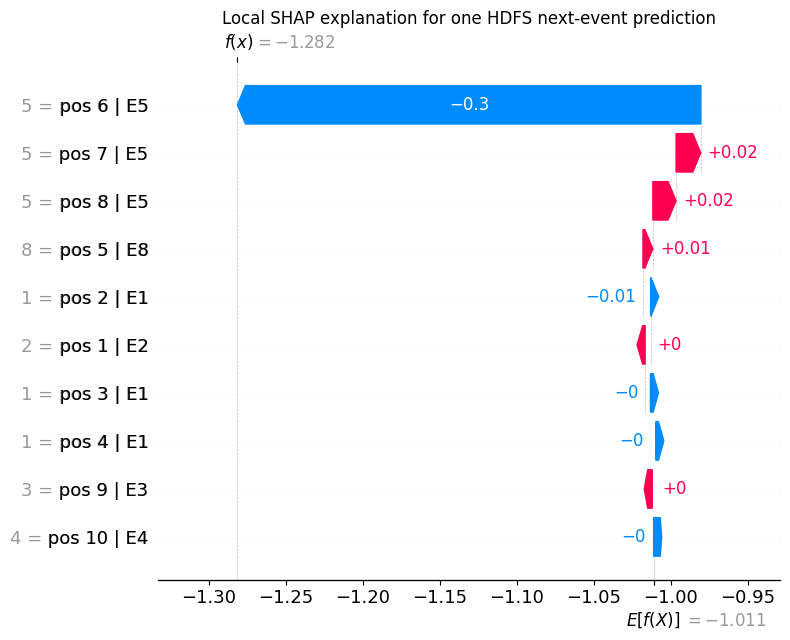

In [19]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Prepare readable feature names: source position + EventID
shap_display = shap_df.sort_values("src_position").copy()

feature_names = [
    f"pos {int(pos)} | E{int(event)}"
    for pos, event in zip(
        shap_display["src_position"],
        shap_display["src_event_id"]
    )
]

# Rebuild SHAP explanation with clearer feature labels
local_exp = shap.Explanation(
    values=shap_display["shap_value"].to_numpy(),
    base_values=float(shap_display["base_value"].iloc[0]),
    data=shap_display["src_event_id"].to_numpy(),
    feature_names=feature_names
)

# SHAP built-in waterfall plot
shap.plots.waterfall(
    local_exp,
    max_display=10,
    show=False
)

plt.title("Local SHAP explanation for one HDFS next-event prediction")
plt.tight_layout()
plt.savefig("local_shap_waterfall.png", dpi=300, bbox_inches="tight")
plt.show()